In [1]:
from helpers.data import load_binance_1h_data, resample_ohlcv
from helpers.backtest import backtest_sma
import numpy as np
import pandas as pd
pd.set_option("display.max_columns", None)
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

In [2]:
btc_ohlcv_1h = load_binance_1h_data()
btc_ohlcv_1h['time'] = pd.to_datetime(btc_ohlcv_1h['time'], utc=True)

In [3]:
btc_ohlcv_1h

,time,open,high,low,close,Volume,RSI,RSI-based MA,Regular Bullish,Regular Bullish Label,Regular Bearish,Regular Bearish Label
0,2024-01-01 00:00:00+00:00,42283.58,42554.57,42261.02,42475.23,1271.68108,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-01-01 01:00:00+00:00,42475.23,42775.00,42431.65,42613.56,1196.37856,NaN,NaN,NaN,NaN,NaN,NaN
2,2024-01-01 02:00:00+00:00,42613.57,42638.41,42500.00,42581.10,685.21980,NaN,NaN,NaN,NaN,NaN,NaN
3,2024-01-01 03:00:00+00:00,42581.09,42586.64,42230.08,42330.49,794.80391,NaN,NaN,NaN,NaN,NaN,NaN
4,2024-01-01 04:00:00+00:00,42330.50,42399.99,42209.46,42399.99,715.41760,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
23891,2026-09-22 11:00:00+00:00,85904.00,86142.01,85774.27,85986.62,661.52703,61.220590,63.560526,NaN,NaN,NaN,NaN
23892,2026-09-22 12:00:00+00:00,85986.62,86182.20,85782.52,86024.01,1020.45206,61.656782,62.449630,NaN,NaN,NaN,NaN
23893,2026-09-22 13:00:00+00:00,86024.01,86370.00,85569.46,86346.01,1218.84156,65.278842,61.530761,NaN,NaN,NaN,NaN
23894,2026-09-22 14:00:00+00:00,86346.01,86470.58,85461.53,86258.01,1551.74098,63.513042,61.390801,NaN,NaN,NaN,NaN


In [4]:
windows = range(5,155,5)

results = []
backtest = {}

# Backtest for each SMA window size
for window in windows:
    result = backtest_sma(btc_ohlcv_1h, window)
    sharpe = (result['pl'].mean()/result['pl'].std())*np.sqrt(365)
    backtest[window] = result
    results.append({
        "window": window,
        "total_pl": result["cumulative_pl"].iloc[-1],
        "sharpe": sharpe
    })

results_df = pd.DataFrame(results)

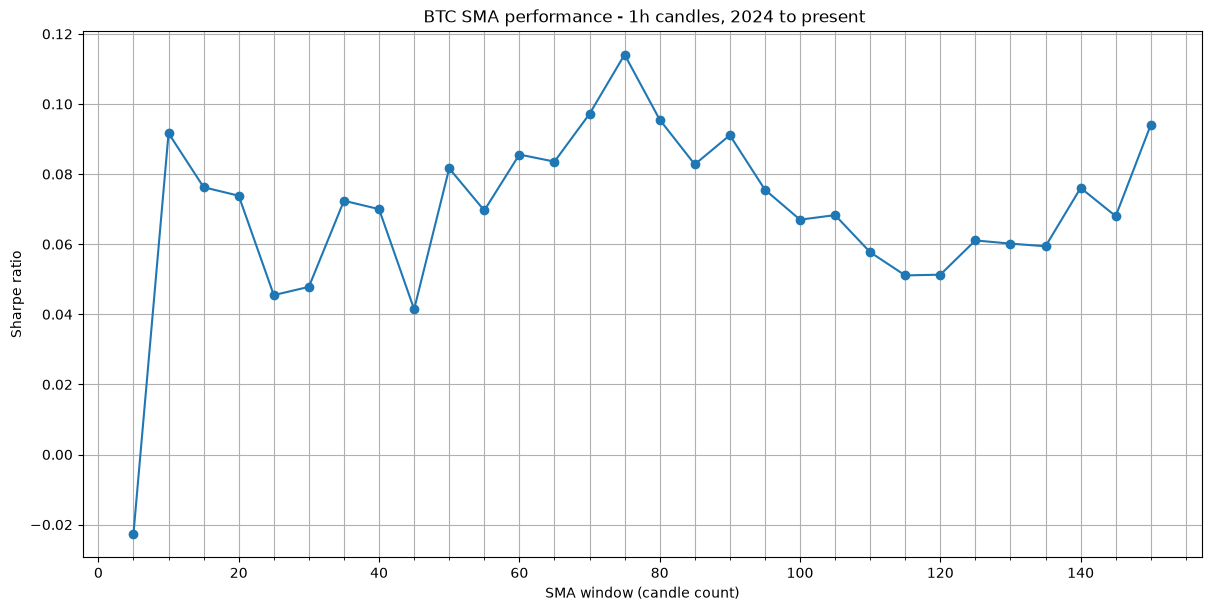

In [5]:
fig, ax = plt.subplots(figsize=(12, 6), layout='constrained')
ax.plot(results_df["window"], results_df["sharpe"], marker="o")
ax.set_xlabel("SMA window (candle count)")
ax.set_ylabel("Sharpe ratio")
ax.set_title(" BTC SMA performance - 1h candles, 2024 to present")
ax.grid(which='both')
ax.xaxis.set_minor_locator(MultipleLocator(5))

Text(0, 0.5, 'dollars')

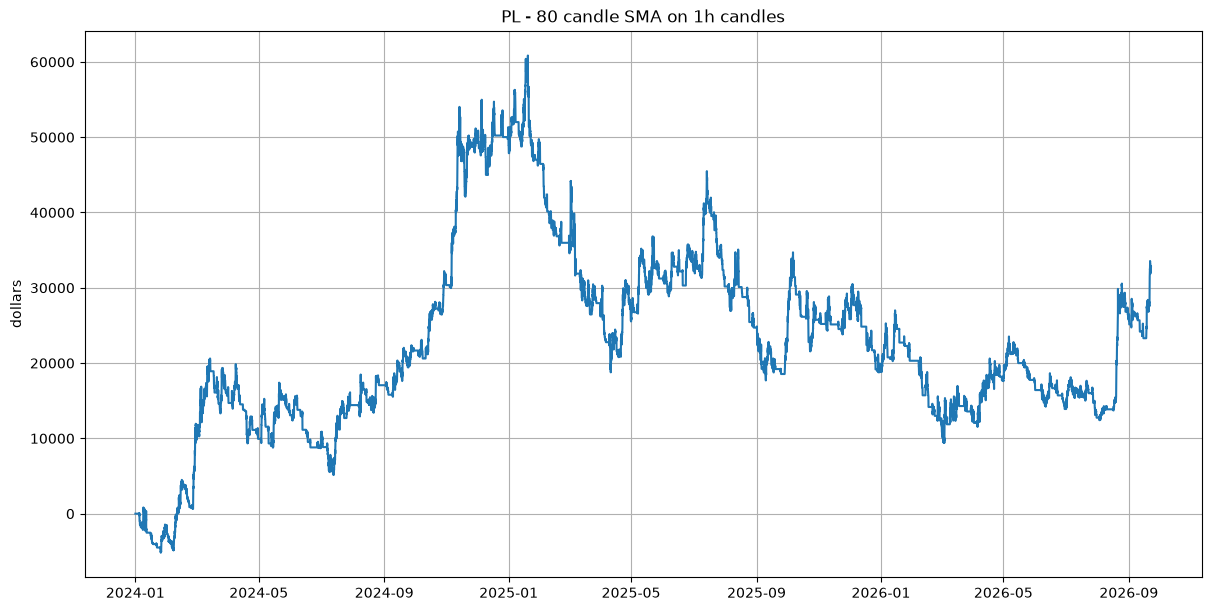

In [6]:

fig, ax = plt.subplots(figsize=(12, 6), layout='constrained')
ax.set(title='PL - 80 candle SMA on 1h candles')
ax.plot(backtest[80]['time'], backtest[80]['cumulative_pl'])
ax.grid(which='both')
ax.set_ylabel('dollars')